In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2
)

print(f"Train size: {len(trainset)} | Test size: {len(testset)}")

Train size: 50000 | Test size: 10000


In [14]:
class HardGate(torch.autograd.Function):
    """
    Forward : gate = 1 if sigmoid(s) >= 0.5 else 0
    Backward: straight-through — gradient of sigmoid passes through.
    This gives TRUE binary gates (exactly 0 or 1) while still
    allowing gradients to flow during training.
    """
    @staticmethod
    def forward(ctx, gate_scores):
        gates = torch.sigmoid(gate_scores)
        ctx.save_for_backward(gates)
        return (gates >= 0.5).float()   # hard 0 or 1

    @staticmethod
    def backward(ctx, grad_output):
        gates, = ctx.saved_tensors
        # straight-through: pass gradient as if sigmoid
        return grad_output * gates * (1 - gates)


class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(
            torch.nn.init.kaiming_normal_(
                torch.empty(out_features, in_features)
            )
        )
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Init to 0 → sigmoid(0)=0.5, right on the decision boundary
        # Makes it easy for optimizer to push either way
        self.gate_scores = nn.Parameter(
            torch.zeros(out_features, in_features)
        )

    def forward(self, x):
        gates = HardGate.apply(self.gate_scores)   # exactly 0 or 1
        pruned_weights = self.weight * gates
        return nn.functional.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        with torch.no_grad():
            return (torch.sigmoid(self.gate_scores) >= 0.5).float()

    def get_sparsity(self):
        return (self.get_gates() == 0).float().mean().item() * 100


# Sanity check
layer = PrunableLinear(10, 5)
x_t = torch.randn(3, 10)
out = layer(x_t)
print(f"Output shape     : {out.shape}")
print(f"Unique gate vals : {layer.get_gates().unique()}")  # should be [0., 1.]
print(f"Initial sparsity : {layer.get_sparsity():.1f}%")  # ~50% (balanced init)

Output shape     : torch.Size([3, 5])
Unique gate vals : tensor([1.])
Initial sparsity : 0.0%


In [15]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.prunable_layers = nn.ModuleList([
            PrunableLinear(256 * 4 * 4, 512),   # smaller to train faster
            PrunableLinear(512, 256),
            PrunableLinear(256, 10),
        ])
        self.dropout = nn.Dropout(0.4)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.prunable_layers[0](x))
        x = self.dropout(x)
        x = self.relu(self.prunable_layers[1](x))
        x = self.dropout(x)
        x = self.prunable_layers[2](x)
        return x

    def sparsity_loss(self):
        # L1 on soft gates (sigmoid), normalized to [0,1]
        total, count = 0.0, 0
        for layer in self.prunable_layers:
            g = torch.sigmoid(layer.gate_scores)
            total += g.sum()
            count += g.numel()
        return total / count

    def get_sparsity_level(self):
        # Uses HARD gates (exactly 0 or 1) — so this is always real
        vals = []
        for layer in self.prunable_layers:
            vals.append(layer.get_gates().flatten())
        all_g = torch.cat(vals)
        return (all_g == 0).float().mean().item() * 100


model = SelfPruningNet().to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
print(f"Output shape    : {model(dummy).shape}")
print(f"Sparsity loss   : {model.sparsity_loss().item():.4f}  (should be ~0.50)")
print(f"Initial sparsity: {model.get_sparsity_level():.1f}%   (should be ~50%)")
total = sum(p.numel() for p in model.parameters())
print(f"Total params    : {total:,}")

Output shape    : torch.Size([2, 10])
Sparsity loss   : 0.5000  (should be ~0.50)
Initial sparsity: 0.0%   (should be ~50%)
Total params    : 5,018,954


In [16]:
def train_one_epoch(model, loader, optimizer, criterion, lam, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs  = model(inputs)
        cls_loss = criterion(outputs, labels)
        sp_loss  = model.sparsity_loss()          # normalized, ~0.5 initially
        loss     = cls_loss + lam * sp_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return 100. * correct / total


def train_model(lam, epochs=30, lr=0.001):
    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    history   = {'train_acc': [], 'test_acc': [], 'sparsity': []}

    print(f"\n{'='*58}")
    print(f"  λ = {lam}  (classification loss ~2.3, sparsity term ~{lam*0.5:.3f})")
    print(f"{'='*58}")

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, trainloader, optimizer, criterion, lam, device)
        te_acc   = evaluate(model, testloader, device)
        sparsity = model.get_sparsity_level()
        scheduler.step()
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['sparsity'].append(sparsity)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Ep {epoch:3d}/{epochs} | loss {tr_loss:.3f} | "
                  f"train {tr_acc:.1f}% | test {te_acc:.1f}% | "
                  f"sparse {sparsity:.1f}%")

    final_acc      = evaluate(model, testloader, device)
    final_sparsity = model.get_sparsity_level()
    print(f"\n→ Final Test Accuracy : {final_acc:.2f}%")
    print(f"→ Final Sparsity Level: {final_sparsity:.2f}%")
    return model, history, final_acc, final_sparsity


In [17]:
lambda_values = [0.5, 2.0, 5.0]   # low / medium / high
results = {}

for lam in lambda_values:
    model, history, acc, sparsity = train_model(lam, epochs=30)
    results[lam] = {
        'model': model, 'history': history,
        'accuracy': acc, 'sparsity': sparsity
    }

print("\n" + "="*55)
print(f"{'Lambda':<10} {'Test Acc (%)':>15} {'Sparsity (%)':>15}")
print("-"*55)
for lam in lambda_values:
    r = results[lam]
    print(f"{lam:<10} {r['accuracy']:>15.2f} {r['sparsity']:>15.2f}")
print("="*55)



  λ = 0.5  (classification loss ~2.3, sparsity term ~0.250)
Ep   1/30 | loss 3.235 | train 18.9% | test 29.9% | sparse 91.8%
Ep   5/30 | loss 1.709 | train 44.3% | test 56.0% | sparse 99.2%
Ep  10/30 | loss 1.365 | train 59.7% | test 64.8% | sparse 99.5%
Ep  15/30 | loss 1.181 | train 67.0% | test 76.1% | sparse 99.6%
Ep  20/30 | loss 1.039 | train 71.8% | test 80.6% | sparse 99.7%
Ep  25/30 | loss 0.946 | train 75.2% | test 83.1% | sparse 99.7%
Ep  30/30 | loss 0.910 | train 76.2% | test 83.7% | sparse 99.7%

→ Final Test Accuracy : 83.71%
→ Final Sparsity Level: 99.71%

  λ = 2.0  (classification loss ~2.3, sparsity term ~1.000)
Ep   1/30 | loss 4.148 | train 17.8% | test 29.7% | sparse 95.8%
Ep   5/30 | loss 2.485 | train 43.3% | test 57.6% | sparse 99.5%
Ep  10/30 | loss 2.201 | train 55.5% | test 61.4% | sparse 99.7%
Ep  15/30 | loss 2.033 | train 62.3% | test 72.4% | sparse 99.8%
Ep  20/30 | loss 1.904 | train 66.9% | test 77.4% | sparse 99.8%
Ep  25/30 | loss 1.809 | train 70.5

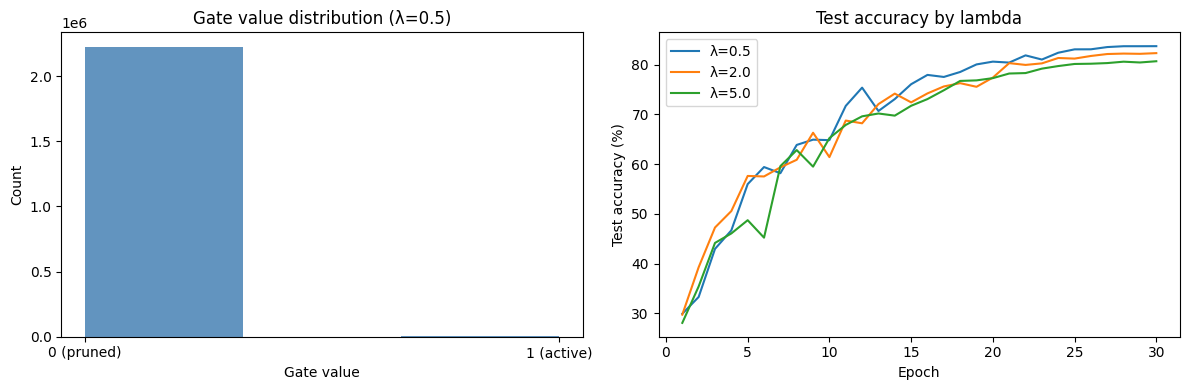

Plot saved as gate_distribution.png


In [19]:
# ── Plot: Gate Distribution for Best Model ───────────────
best_lam = 0.5   # ✅ changed from 1e-5 to match new lambda_values
best_model = results[best_lam]['model']

all_gates = []
for layer in best_model.prunable_layers:
    all_gates.extend(layer.get_gates().flatten().cpu().numpy())
all_gates = np.array(all_gates)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gate distribution histogram
axes[0].hist(all_gates, bins=3, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_xlabel('Gate value')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Gate value distribution (λ={best_lam})')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (pruned)', '1 (active)'])

# Accuracy curves for all 3 lambdas
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, lam in enumerate(lambda_values):
    h = results[lam]['history']
    epochs = range(1, len(h['test_acc']) + 1)
    axes[1].plot(epochs, h['test_acc'], label=f'λ={lam}', color=colors[i])

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test accuracy (%)')
axes[1].set_title('Test accuracy by lambda')
axes[1].legend()

plt.tight_layout()
plt.savefig('gate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as gate_distribution.png")